# Proyecto Integrador: Threat Hunting basado en Machine Learning sobre Kubernetes
## Dataset: Integrated Cloud Security 3Datasets (ICS3D)
### Framework de Procesamiento Distribuido con PySpark MLlib

---

| Campo | Detalle |
|---|---|
| **Asignatura** | Procesamiento de Grandes Volúmenes de Datos (Big Data) |
| **Dataset** | Integrated Cloud Security 3Datasets — `Containers_Dataset.csv` |
| **Tecnología principal** | Apache Spark / PySpark MLlib |
| **Objetivo** | Detección de TTPs (Tactics, Techniques & Procedures) en entornos Kubernetes mediante ML distribuido |

---

## Estructura del Proyecto

Este notebook integra de forma ordenada todas las etapas del proyecto:

1. **Sección 1 — Lectura del Dataset Original**
2. **Sección 2 — Construcción de Variables de Caracterización y Análisis Exploratorio**
3. **Sección 3 — Construcción de la Muestra M (Muestreo Estratificado con Balanceo Parcial)**
4. **Sección 4 — Pre-procesamiento y Limpieza de la Muestra**
5. **Sección 5 — División Train / Test Estratificada**
6. **Sección 6 — Ingeniería de Características (Feature Engineering Pipeline)**
7. **Sección 7 — Fase de Experimentación Supervisada: Random Forest con Validación Cruzada**
8. **Sección 8 — Fase de Experimentación No Supervisada: K-Means Clustering**
9. **Sección 9 — Validación Cruzada K-Fold Estratificada (k=5)**
10. **Sección 10 — Visualización e Interpretación de Resultados**
11. **Sección 11 — Conclusiones y Discusión**


## Autores

- **Juan Pablo Salazar Pérez** — A01796000  
- **Carlos Isaac Sagrero Campos** — A01796826  
- **Fernando Omar Salazar Ortiz** — A01796214  
- **Mario Arturo Salinas Rodríguez** — A01796938  


---
## Marco Teórico

### Contexto del Problema
El dataset **ICS3D (Integrated Cloud Security 3Datasets)** captura tráfico de red generado en un clúster Kubernetes con microservicios desplegados. Contiene más de **3.2 millones de flujos de red** etiquetados con 12 tipos de tráfico: uno benigno (`Label=0`) y 11 tipos de ataques clasificados según el marco MITRE ATT&CK para contenedores.

### Aprendizaje Supervisado
El **Aprendizaje Supervisado** opera sobre un conjunto $\mathcal{D} = \{(x_1,y_1),\dots,(x_N,y_N)\}$ donde el objetivo es aproximar $f: X \to Y$ minimizando una función de pérdida. En este proyecto usamos:
- **Random Forest:** conjunto de árboles de decisión que reduce varianza y sesgo simultáneamente mediante bagging y selección aleatoria de características.

### Aprendizaje No Supervisado
El **Aprendizaje No Supervisado** descubre estructuras latentes en $\mathcal{D} = \{x_1,\dots,x_N\}$ sin etiquetas. Usamos:
- **K-Means:** particiona $N$ observaciones en $k$ clústeres minimizando la suma de distancias al centroide.

### Métricas de Calidad
Para clasificación multiclase con desbalance de clases se usan:
$$Precision = \frac{TP}{TP+FP}, \quad Recall = \frac{TP}{TP+FN}, \quad F_1 = 2\cdot\frac{Precision \cdot Recall}{Precision + Recall}$$

Para clustering:
$$s(i) = \frac{b(i)-a(i)}{\max(a(i),b(i))} \in [-1, 1]$$


---
## Sección 1 — Inicialización de PySpark y Lectura del Dataset Original


In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Inicializar sesión de Spark optimizada para MLlib
spark = (
    SparkSession.builder
    .appName("ICS3D_ThreatHunting_Proyecto_Integrador")
    .config("spark.driver.memory", "6g")
    .config("spark.executor.memory", "6g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.shuffle.partitions", "50")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Sesión de PySpark iniciada. Versión Spark: {spark.version} | Python: {sys.version.split()[0]}")


Sesión de PySpark iniciada. Versión Spark: 4.1.1 | Python: 3.12.13


In [2]:
# ─── LECTURA DEL DATASET ORIGINAL ────────────────────────────────────────────
# NOTA: Ajustar 'file_path' a la ubicación local del archivo Containers_Dataset.csv
file_path = r"C:\Users\juanc\OneDrive\Maestria 2024\grandes volumentes de datos\Actividad 1\Containers_Dataset.csv"

try:
    df_raw = spark.read.csv(file_path, header=True, inferSchema=True)
    total_records = df_raw.count()
    total_cols    = len(df_raw.columns)
    print(f"Dataset cargado exitosamente.")
    print(f"  Registros totales : {total_records:,}")
    print(f"  Columnas          : {total_cols}")
    df_raw.printSchema()

except Exception as e:
    # ── Fallback: datos sintéticos representativos si el CSV no está disponible ──
    print(f"Aviso: no se encontró el archivo CSV. Generando datos sintéticos.\nDetalle: {e}")
    import random
    from pyspark.sql.types import (StructType, StructField,
                                   IntegerType, DoubleType)
    random.seed(42)
    schema = StructType([
        StructField("Flow Duration",              DoubleType(), True),
        StructField("Total Fwd Packet",           DoubleType(), True),
        StructField("Total Bwd packets",          DoubleType(), True),
        StructField("Total Length of Fwd Packet", DoubleType(), True),
        StructField("Total Length of Bwd Packet", DoubleType(), True),
        StructField("Flow Bytes/s",               DoubleType(), True),
        StructField("Flow Packets/s",             DoubleType(), True),
        StructField("Average Packet Size",        DoubleType(), True),
        StructField("Fwd Packet Length Mean",     DoubleType(), True),
        StructField("Bwd Packet Length Mean",     DoubleType(), True),
        StructField("FIN Flag Count",             DoubleType(), True),
        StructField("SYN Flag Count",             DoubleType(), True),
        StructField("RST Flag Count",             DoubleType(), True),
        StructField("Protocol",                   IntegerType(), True),
        StructField("Label",                      IntegerType(), True),
    ])
    label_weights = [0]*91 + [1]*3 + [2]*5 + [3]*1  # ~91% benigno
    rows = []
    for _ in range(100_000):
        lbl = random.choice(label_weights)
        rows.append((
            float(random.randint(10, 5_000_000)),
            float(random.randint(1, 200)),
            float(random.randint(1, 200)),
            float(random.randint(64, 65_535)),
            float(random.randint(64, 65_535)),
            float(random.uniform(10.0, 1_000_000.0)),
            float(random.uniform(0.1, 5_000.0)),
            float(random.uniform(32.0, 1_500.0)),
            float(random.uniform(32.0, 1_000.0)),
            float(random.uniform(32.0, 1_000.0)),
            float(random.choice([0, 1])),
            float(random.choice([0, 1])),
            float(random.choice([0, 1])),
            int(random.choice([6, 17, 0])),
            int(lbl),
        ))
    df_raw = spark.createDataFrame(rows, schema)
    total_records = df_raw.count()
    print(f"Dataset sintético creado: {total_records:,} registros, {len(df_raw.columns)} columnas.")


Dataset cargado exitosamente.
  Registros totales : 3,231,475
  Columnas          : 87
root
 |-- Flow ID: string (nullable = true)
 |-- Src IP: string (nullable = true)
 |-- Src Port: integer (nullable = true)
 |-- Dst IP: string (nullable = true)
 |-- Dst Port: integer (nullable = true)
 |-- Protocol: integer (nullable = true)
 |-- Timestamp: timestamp (nullable = true)
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packet: integer (nullable = true)
 |-- Total Bwd packets: integer (nullable = true)
 |-- Total Length of Fwd Packet: double (nullable = true)
 |-- Total Length of Bwd Packet: double (nullable = true)
 |-- Fwd Packet Length Max: double (nullable = true)
 |-- Fwd Packet Length Min: double (nullable = true)
 |-- Fwd Packet Length Mean: double (nullable = true)
 |-- Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: double (nullable = true)
 |-- Bwd Packet Length Min: double (nullable = true)
 |-- Bwd Packet Length Mean: double (nullable 

---
## Sección 2 — Exploración Inicial y Construcción de Variables de Caracterización

Las variables de caracterización son la base del proceso de particionamiento y muestreo estratificado. Se definen tres variables derivadas:

| Variable | Fuente | Descripción |
|---|---|---|
| `traffic_type` | `Label` | Benigno (`Label=0`) vs. Malicioso (`Label≠0`) |
| `protocol_type` | `Protocol` | TCP (6), UDP (17), Other |
| `traffic_intensity` | `Flow Bytes/s` | Low / Medium / High según percentiles p33 y p66 |

Los percentiles de `Flow Bytes/s` fueron calculados previamente sobre la población completa:
- **p33 = 15,841.91** bytes/s
- **p66 = 66,084.98** bytes/s


In [3]:
# ─── EXPLORACIÓN INICIAL ──────────────────────────────────────────────────────
print("=== Distribución de la variable objetivo (Label) ===")
df_raw.groupBy("Label").count() \
    .withColumn("Porcentaje_%", F.round(F.col("count") / total_records * 100, 4)) \
    .orderBy(F.col("count").desc()) \
    .show(20, truncate=False)


=== Distribución de la variable objetivo (Label) ===
+-----+-------+------------+
|Label|count  |Porcentaje_%|
+-----+-------+------------+
|0    |2953291|91.3914     |
|2    |156614 |4.8465      |
|1    |111251 |3.4427      |
|11   |8722   |0.2699      |
|8    |824    |0.0255      |
|6    |193    |0.006       |
|3    |168    |0.0052      |
|4    |163    |0.005       |
|7    |131    |0.0041      |
|10   |48     |0.0015      |
|5    |36     |0.0011      |
|9    |34     |0.0011      |
+-----+-------+------------+



In [4]:
# ─── VARIABLE 1: traffic_type ─────────────────────────────────────────────────
df = df_raw.withColumn(
    "traffic_type",
    F.when(F.col("Label").cast("int") == 0, "Benign").otherwise("Malicious")
)

print("Distribución traffic_type:")
df.groupBy("traffic_type").count() \
    .withColumn("Porcentaje_%", F.round(F.col("count") / total_records * 100, 4)) \
    .show()


Distribución traffic_type:
+------------+-------+------------+
|traffic_type|  count|Porcentaje_%|
+------------+-------+------------+
|      Benign|2953291|     91.3914|
|   Malicious| 278184|      8.6086|
+------------+-------+------------+



In [5]:
# ─── VARIABLE 2: protocol_type ────────────────────────────────────────────────
df = df.withColumn(
    "protocol_type",
    F.when(F.col("Protocol").cast("int") == 6,  "TCP")
     .when(F.col("Protocol").cast("int") == 17, "UDP")
     .otherwise("Other")
)

print("Distribución protocol_type:")
df.groupBy("protocol_type").count() \
    .withColumn("Porcentaje_%", F.round(F.col("count") / total_records * 100, 4)) \
    .show()


Distribución protocol_type:
+-------------+-------+------------+
|protocol_type|  count|Porcentaje_%|
+-------------+-------+------------+
|          UDP|  63671|      1.9703|
|          TCP|3160045|     97.7896|
|        Other|   7759|      0.2401|
+-------------+-------+------------+



In [6]:
# ─── CÁLCULO DE PERCENTILES p33 y p66 para Flow Bytes/s ──────────────────────
# Valores empíricos del dataset original ICS3D (Evidencia 1 - Equipo 64)
P33 = 15841.905766121878
P66 = 66084.97723823975

print(f"Percentil 33 (p33) de Flow Bytes/s : {P33:,.4f}")
print(f"Percentil 66 (p66) de Flow Bytes/s : {P66:,.4f}")
print()
print("Nota: Estos valores fueron calculados con approxQuantile sobre la población completa.")
print("      Se reutilizan para garantizar consistencia entre actividades.")


Percentil 33 (p33) de Flow Bytes/s : 15,841.9058
Percentil 66 (p66) de Flow Bytes/s : 66,084.9772

Nota: Estos valores fueron calculados con approxQuantile sobre la población completa.
      Se reutilizan para garantizar consistencia entre actividades.


In [7]:
# ─── VARIABLE 3: traffic_intensity ────────────────────────────────────────────
df = df.withColumn(
    "traffic_intensity",
    F.when(F.col("Flow Bytes/s") <= P33, "Low")
     .when((F.col("Flow Bytes/s") > P33) & (F.col("Flow Bytes/s") <= P66), "Medium")
     .otherwise("High")
)

print("Distribución traffic_intensity:")
df.groupBy("traffic_intensity").count() \
    .withColumn("Porcentaje_%", F.round(F.col("count") / total_records * 100, 4)) \
    .orderBy("traffic_intensity") \
    .show()


Distribución traffic_intensity:
+-----------------+-------+------------+
|traffic_intensity|  count|Porcentaje_%|
+-----------------+-------+------------+
|             High|1138365|     35.2274|
|              Low|1041544|     32.2312|
|           Medium|1051566|     32.5414|
+-----------------+-------+------------+



In [8]:
# ─── CLAVE DE ESTRATO (strata_key) ────────────────────────────────────────────
df = df.withColumn(
    "strata_key",
    F.concat_ws("_",
                F.col("traffic_type"),
                F.col("protocol_type"),
                F.col("traffic_intensity"))
)

print("=== Distribución completa de particiones (strata_key) ===")
partition_dist = df.groupBy("traffic_type", "protocol_type", "traffic_intensity", "strata_key") \
    .count() \
    .withColumn("Probabilidad", F.round(F.col("count") / total_records, 6)) \
    .orderBy(F.col("count").desc())

partition_dist.show(20, truncate=False)

# Vista SQL para consultas analíticas
df.createOrReplaceTempView("ics3d_flows")
print("Vista SQL 'ics3d_flows' creada.")


=== Distribución completa de particiones (strata_key) ===
+------------+-------------+-----------------+--------------------+-------+------------+
|traffic_type|protocol_type|traffic_intensity|strata_key          |count  |Probabilidad|
+------------+-------------+-----------------+--------------------+-------+------------+
|Benign      |TCP          |Medium           |Benign_TCP_Medium   |1045988|0.323687    |
|Benign      |TCP          |Low              |Benign_TCP_Low      |996581 |0.308398    |
|Benign      |TCP          |High             |Benign_TCP_High     |863037 |0.267072    |
|Malicious   |TCP          |High             |Malicious_TCP_High  |229279 |0.070952    |
|Benign      |UDP          |High             |Benign_UDP_High     |36637  |0.011338    |
|Malicious   |TCP          |Low              |Malicious_TCP_Low   |20855  |0.006454    |
|Malicious   |UDP          |Low              |Malicious_UDP_Low   |11651  |0.003605    |
|Malicious   |UDP          |High             |Malici

In [9]:
# ─── FUNCIÓN UTILITARIA: EXTRACCIÓN DE SUBMUESTRAS POR PARTICIÓN ───────────────
def get_partition_sample(traffic_type, protocol_type, traffic_intensity, sample_size=10):
    """Extrae una submuestra de registros de una partición específica vía Spark SQL."""
    query = f"""
        SELECT Label, Protocol, `Flow Bytes/s`,
               traffic_type, protocol_type, traffic_intensity
        FROM   ics3d_flows
        WHERE  traffic_type       = '{traffic_type}'
          AND  protocol_type      = '{protocol_type}'
          AND  traffic_intensity  = '{traffic_intensity}'
        LIMIT  {sample_size}
    """
    return spark.sql(query)

# ── Ejemplos de validación ──
print("Ejemplo 1 — Benigno / TCP / Low:")
get_partition_sample("Benign", "TCP", "Low", 5).show(truncate=False)

print("Ejemplo 2 — Malicioso / TCP / High:")
get_partition_sample("Malicious", "TCP", "High", 5).show(truncate=False)

print("Ejemplo 3 — Benigno / UDP / High:")
get_partition_sample("Benign", "UDP", "High", 5).show(truncate=False)


Ejemplo 1 — Benigno / TCP / Low:
+-----+--------+------------------+------------+-------------+-----------------+
|Label|Protocol|Flow Bytes/s      |traffic_type|protocol_type|traffic_intensity|
+-----+--------+------------------+------------+-------------+-----------------+
|0    |6       |7075.620627241754 |Benign      |TCP          |Low              |
|0    |6       |6734.636892821606 |Benign      |TCP          |Low              |
|0    |6       |0.0               |Benign      |TCP          |Low              |
|0    |6       |3.7344453456644655|Benign      |TCP          |Low              |
|0    |6       |13.94062198230764 |Benign      |TCP          |Low              |
+-----+--------+------------------+------------+-------------+-----------------+

Ejemplo 2 — Malicioso / TCP / High:
+-----+--------+--------------------+------------+-------------+-----------------+
|Label|Protocol|Flow Bytes/s        |traffic_type|protocol_type|traffic_intensity|
+-----+--------+-------------------

---
## Sección 3 — Construcción de la Muestra M

### Justificación del Muestreo Estratificado con Balanceo Parcial

El dataset ICS3D exhibe un desbalance severo: el tráfico benigno concentra más del **91%** de los registros. Un muestreo aleatorio simple provocaría **sesgo de exclusión** eliminando virtualmente los subtipos de ataques minoritarios.

La estrategia adoptada combina:

1. **Estratos Benignos → Fracción proporcional:** $f_i = \frac{n_{\text{objetivo}}}{N}$, conservando la distribución a priori.

2. **Estratos Maliciosos → Sobremuestreo selectivo:** basado en la fórmula de Cochran:
$$n_0 = \frac{Z^2 \cdot p(1-p)}{e^2} \approx 384 \text{ (mínimo estadístico)}$$
Con margen conservador de **1,200 registros** por estrato malicioso cuando la población lo permite.

Esta combinación garantiza que $M = \bigcup M_i$ sea estadísticamente representativa sin inyectar sesgo artificial.


In [10]:
# ─── CÁLCULO DE FRACCIONES DE MUESTREO ───────────────────────────────────────
strata_counts  = df.groupBy("strata_key").count().collect()
total_p        = df.count()

# Tamaño objetivo benigno (procesamiento local óptimo)
TARGET_BENIGN  = 30_000
prop_fraction  = TARGET_BENIGN / total_p

print(f"Población total (N)         : {total_p:,}")
print(f"Fracción proporcional base  : {prop_fraction:.6f}  (~{prop_fraction*100:.3f}%)")
print()

fractions = {}
for row in strata_counts:
    key   = row["strata_key"]
    count = row["count"]
    if "Malicious" in key:
        # Criterio de Cochran ajustado: mínimo 1,200 o 35% del sub-estrato
        desired = min(count, max(1_200, int(count * 0.35)))
        fractions[key] = min(1.0, desired / count)
    else:
        fractions[key] = min(1.0, prop_fraction)

print("Fracciones de muestreo asignadas por estrato:")
print(f"{'Estrato':<38} {'Fracción':>10}  {'Tipo'}")
print("-" * 62)
for k, v in sorted(fractions.items()):
    tipo = "MALICIOSO (sobremuestreado)" if "Malicious" in k else "Benigno (proporcional)"
    print(f"{k:<38} {v:>10.5f}  {tipo}")


Población total (N)         : 3,231,475
Fracción proporcional base  : 0.009284  (~0.928%)

Fracciones de muestreo asignadas por estrato:
Estrato                                  Fracción  Tipo
--------------------------------------------------------------
Benign_Other_High                         0.00928  Benigno (proporcional)
Benign_Other_Low                          0.00928  Benigno (proporcional)
Benign_TCP_High                           0.00928  Benigno (proporcional)
Benign_TCP_Low                            0.00928  Benigno (proporcional)
Benign_TCP_Medium                         0.00928  Benigno (proporcional)
Benign_UDP_High                           0.00928  Benigno (proporcional)
Benign_UDP_Low                            0.00928  Benigno (proporcional)
Benign_UDP_Medium                         0.00928  Benigno (proporcional)
Malicious_Other_Low                       0.47544  MALICIOSO (sobremuestreado)
Malicious_TCP_High                        0.35000  MALICIOSO (sobremuestr

In [11]:
# ─── EXTRACCIÓN DETERMINISTA DE LA MUESTRA M ─────────────────────────────────
M_raw = df.sampleBy("strata_key", fractions, seed=42)
m_size = M_raw.count()

print(f"Tamaño de la muestra M (antes de limpieza): {m_size:,} registros")
print()
print("Distribución de estratos en M:")
M_raw.groupBy("strata_key", "traffic_type").count() \
    .withColumn("% en M", F.round(F.col("count") / m_size * 100, 3)) \
    .orderBy(F.col("count").desc()) \
    .show(20, truncate=False)


Tamaño de la muestra M (antes de limpieza): 125,754 registros

Distribución de estratos en M:
+--------------------+------------+-----+------+
|strata_key          |traffic_type|count|% en M|
+--------------------+------------+-----+------+
|Malicious_TCP_High  |Malicious   |80531|64.039|
|Benign_TCP_Medium   |Benign      |9684 |7.701 |
|Benign_TCP_Low      |Benign      |9434 |7.502 |
|Benign_TCP_High     |Benign      |8199 |6.52  |
|Malicious_TCP_Low   |Malicious   |7366 |5.857 |
|Malicious_UDP_Low   |Malicious   |4019 |3.196 |
|Malicious_UDP_High  |Malicious   |3326 |2.645 |
|Malicious_TCP_Medium|Malicious   |1478 |1.175 |
|Malicious_Other_Low |Malicious   |1188 |0.945 |
|Benign_UDP_High     |Benign      |296  |0.235 |
|Malicious_UDP_Medium|Malicious   |165  |0.131 |
|Benign_UDP_Low      |Benign      |33   |0.026 |
|Benign_Other_Low    |Benign      |28   |0.022 |
|Benign_UDP_Medium   |Benign      |7    |0.006 |
+--------------------+------------+-----+------+



---
## Sección 4 — Pre-procesamiento y Limpieza de la Muestra M

Las métricas de flujo de red presentan tres tipos de ruido habitual:

1. **Valores Infinitos:** `Flow Bytes/s` y `Flow Packets/s` producen `Inf` cuando la duración del flujo es 0 µs (división por cero). Se reemplazan por `null`.
2. **Valores Nulos / NaN:** Imputados con la **mediana** (robusta ante distribuciones sesgadas).
3. **Outliers en tráfico benigno:** Filtrados únicamente en tráfico benigno usando el límite $Q3 + 3 \cdot IQR$ sobre `Flow Duration`. El tráfico malicioso se conserva íntegro, ya que sus valores atípicos representan la firma del ataque.


In [12]:
from pyspark.ml.feature import Imputer

# ─── PASO 1: Reemplazar Inf y NaN por null ─────────────────────────────────────
EXCLUDE_COLS = {
    "Flow ID", "Src IP", "Dst IP", "Timestamp",
    "Label", "Protocol",
    "traffic_type", "protocol_type", "traffic_intensity", "strata_key"
}
numeric_cols = [c for c, t in M_raw.dtypes
                if t in ("int", "bigint", "long", "double", "float")
                and c not in EXCLUDE_COLS]

M_clean = M_raw
for col_name in numeric_cols:
    M_clean = M_clean.withColumn(
        col_name,
        F.when(
            F.isnan(F.col(col_name))
            | (F.col(col_name) == float("inf"))
            | (F.col(col_name) == float("-inf")),
            None
        ).otherwise(F.col(col_name))
    )

print(f"Columnas numéricas procesadas: {len(numeric_cols)}")
print("Paso 1 completado: Inf y NaN reemplazados por null.")


Columnas numéricas procesadas: 81
Paso 1 completado: Inf y NaN reemplazados por null.


In [13]:
# ─── PASO 2: Imputación por mediana ──────────────────────────────────────────
imputer  = Imputer(inputCols=numeric_cols, outputCols=numeric_cols).setStrategy("median")
M_imputed = imputer.fit(M_clean).transform(M_clean)
print(f"Paso 2 completado: imputación por mediana en {len(numeric_cols)} columnas.")
print(f"Registros tras imputación: {M_imputed.count():,}")


Paso 2 completado: imputación por mediana en 81 columnas.
Registros tras imputación: 125,754


In [14]:
# ─── PASO 3: Filtrado de outliers SOLO en tráfico benigno ────────────────────
q1, q3 = M_imputed.filter(F.col("traffic_type") == "Benign") \
                  .approxQuantile("Flow Duration", [0.25, 0.75], 0.05)
iqr         = q3 - q1
upper_limit = q3 + 3.0 * iqr

print(f"Q1 (Flow Duration): {q1:,.0f} µs")
print(f"Q3 (Flow Duration): {q3:,.0f} µs")
print(f"IQR               : {iqr:,.0f} µs")
print(f"Límite superior   : {upper_limit:,.0f} µs  (Q3 + 3·IQR)")

M_preprocessed = M_imputed.filter(
    (F.col("traffic_type") == "Malicious") |
    ((F.col("traffic_type") == "Benign") & (F.col("Flow Duration") <= upper_limit))
)

pre_count = M_preprocessed.count()
print()
print(f"Muestra M antes de filtrado : {M_imputed.count():,}")
print(f"Muestra M después de filtrado: {pre_count:,}")
print(f"Registros eliminados (benignos atípicos): {M_imputed.count() - pre_count:,}")


Q1 (Flow Duration): 12,646 µs
Q3 (Flow Duration): 110,450 µs
IQR               : 97,804 µs
Límite superior   : 403,862 µs  (Q3 + 3·IQR)

Muestra M antes de filtrado : 125,754
Muestra M después de filtrado: 119,523
Registros eliminados (benignos atípicos): 6,231


---
## Sección 5 — División Train / Test Estratificada

La división global aleatoria introduce **sesgo de covarianza** (*covariate shift*): clases minoritarias pueden quedar ausentes en algún conjunto. Para garantizar:
$$P_{\text{Train}}(X, Y) = P_{\text{Test}}(X, Y)$$

Se implementa una división **estrato por estrato** (80% / 20%), consolidando luego con `union()` paralelo de Spark. Esto asegura $Tr_i \cap Ts_i = \emptyset$ para todo $i$.


In [15]:
# ─── DIVISIÓN ESTRATO POR ESTRATO ─────────────────────────────────────────────
unique_strata = [
    row["strata_key"]
    for row in M_preprocessed.select("strata_key").distinct().collect()
]

train_parts, test_parts = [], []
for stratum in unique_strata:
    sub = M_preprocessed.filter(F.col("strata_key") == stratum)
    tr, ts = sub.randomSplit([0.8, 0.2], seed=42)
    train_parts.append(tr)
    test_parts.append(ts)

# Unión paralela
train_df = train_parts[0]
for p in train_parts[1:]:
    train_df = train_df.union(p)

test_df = test_parts[0]
for p in test_parts[1:]:
    test_df = test_df.union(p)

train_df = train_df.cache()
test_df  = test_df.cache()

n_train = train_df.count()
n_test  = test_df.count()

print(f"Registros en Entrenamiento (80%): {n_train:,}")
print(f"Registros en Prueba       (20%): {n_test:,}")
print(f"Total                           : {n_train + n_test:,}")


Registros en Entrenamiento (80%): 95,397
Registros en Prueba       (20%): 24,126
Total                           : 119,523


In [16]:
# ─── COMPROBACIÓN DE HOMOGENEIDAD ─────────────────────────────────────────────
print("Verificación de distribución de estratos (Train vs Test) [%]:")
train_dist = train_df.groupBy("strata_key").count() \
    .withColumn("Train_%", F.round(F.col("count") / n_train * 100, 2))
test_dist  = test_df.groupBy("strata_key").count() \
    .withColumn("Test_%",  F.round(F.col("count") / n_test  * 100, 2))

comparison = train_dist.join(test_dist, "strata_key") \
    .select("strata_key", "Train_%", "Test_%") \
    .orderBy("strata_key")
comparison.show(truncate=False)


Verificación de distribución de estratos (Train vs Test) [%]:
+--------------------+-------+------+
|strata_key          |Train_%|Test_%|
+--------------------+-------+------+
|Benign_TCP_High     |6.22   |6.07  |
|Benign_TCP_Low      |3.94   |3.95  |
|Benign_TCP_Medium   |7.59   |7.45  |
|Benign_UDP_High     |0.26   |0.22  |
|Benign_UDP_Low      |0.01   |0.01  |
|Benign_UDP_Medium   |0.01   |0.01  |
|Malicious_Other_Low |0.98   |1.07  |
|Malicious_TCP_High  |67.48  |66.98 |
|Malicious_TCP_Low   |6.14   |6.26  |
|Malicious_TCP_Medium|1.21   |1.35  |
|Malicious_UDP_High  |2.74   |2.96  |
|Malicious_UDP_Low   |3.32   |3.54  |
|Malicious_UDP_Medium|0.13   |0.16  |
+--------------------+-------+------+



---
## Sección 6 — Ingeniería de Características (Feature Engineering Pipeline)

### Variables Predictoras Seleccionadas
Se seleccionaron **13 características** de flujo de red con alto poder discriminativo para detectar TTPs en Kubernetes:

| Categoría | Características |
|---|---|
| Temporalidad | `Flow Duration` |
| Volumen de paquetes | `Total Fwd Packet`, `Total Bwd packets` |
| Volumen de bytes | `Total Length of Fwd Packet`, `Total Length of Bwd Packet` |
| Tasas | `Flow Bytes/s`, `Flow Packets/s` |
| Tamaños | `Average Packet Size`, `Fwd Packet Length Mean`, `Bwd Packet Length Mean` |
| Banderas TCP | `FIN Flag Count`, `SYN Flag Count`, `RST Flag Count` |

### Componentes del Pipeline
- **`StringIndexer`:** codifica la etiqueta `Label` (multiclase) en índice numérico.
- **`VectorAssembler`:** ensambla las 13 características en un único vector denso.
- **`StandardScaler`:** estandariza ($\mu=0, \sigma=1$), obligatorio para algoritmos de distancia (K-Means).


In [17]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml import Pipeline

# ─── 13 CARACTERÍSTICAS PREDICTORAS SUPERVISADAS ──────────────────────────────
SELECTED_FEATURES = [
    "Flow Duration",
    "Total Fwd Packet",
    "Total Bwd packets",
    "Total Length of Fwd Packet",
    "Total Length of Bwd Packet",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Average Packet Size",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "FIN Flag Count",
    "SYN Flag Count",
    "RST Flag Count",
]

# 6 CARACTERÍSTICAS PARA K-MEANS (alta varianza, importancia RF > 0.05)
FEATURES_KMEANS = [
    "Flow Packets/s",
    "Flow Bytes/s",
    "Total Length of Fwd Packet",
    "Fwd Packet Length Mean",
    "Flow Duration",
    "Total Length of Bwd Packet",
]

# ─── COMPONENTES DEL PIPELINE ──────────────────────────────────────────────────
label_indexer  = StringIndexer(inputCol="Label", outputCol="label_indexed",
                               handleInvalid="skip")
assembler      = VectorAssembler(inputCols=SELECTED_FEATURES,
                                 outputCol="features_vector")
scaler         = StandardScaler(inputCol="features_vector",
                                outputCol="scaled_features",
                                withStd=True, withMean=True)

# Pipeline para K-Means (propio)
assembler_km   = VectorAssembler(inputCols=FEATURES_KMEANS,
                                 outputCol="features_vector_km")
scaler_km      = StandardScaler(inputCol="features_vector_km",
                                outputCol="scaled_features_km",
                                withStd=True, withMean=True)

print("Componentes de ingeniería de características definidos:")
print(f"  Características supervisadas : {len(SELECTED_FEATURES)}")
print(f"  Características K-Means      : {len(FEATURES_KMEANS)}")


Componentes de ingeniería de características definidos:
  Características supervisadas : 13
  Características K-Means      : 6


---
## Sección 7 — Fase de Experimentación Supervisada: Random Forest con Validación Cruzada

### Estrategia de Modelado
- **Algoritmo:** Random Forest Classifier (robusto ante ruido, alta dimensionalidad y desbalance de clases).
- **Validación Cruzada:** 3-Fold Cross Validation con búsqueda de hiperparámetros (Grid Search).
- **Espacio de búsqueda:** `numTrees ∈ {15, 30}`, `maxDepth ∈ {6, 10}`.
- **Métrica de optimización:** F1-Score ponderado (balance precisión-recall ante desbalance).


In [18]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# ─── PIPELINE SUPERVISADO ─────────────────────────────────────────────────────
rf = RandomForestClassifier(
    labelCol="label_indexed",
    featuresCol="features_vector",
    seed=42
)
pipeline_supervised = Pipeline(stages=[label_indexer, assembler, rf])

# ─── GRID DE HIPERPARÁMETROS ──────────────────────────────────────────────────
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [15, 30])
    .addGrid(rf.maxDepth, [6, 10])
    .build()
)

# ─── EVALUADOR PRIMARIO: F1 ───────────────────────────────────────────────────
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label_indexed",
    predictionCol="prediction",
    metricName="f1"
)

# ─── VALIDACIÓN CRUZADA 3-FOLD ────────────────────────────────────────────────
cv = CrossValidator(
    estimator=pipeline_supervised,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_f1,
    numFolds=3,
    seed=42,
    parallelism=2
)

print("Iniciando entrenamiento con Validación Cruzada 3-Fold...")
print(f"  Combinaciones evaluadas: {len(paramGrid)} parámetros × 3 folds = {len(paramGrid)*3} entrenamientos")
cv_model = cv.fit(train_df)
print("¡Modelo Random Forest entrenado exitosamente!")


Iniciando entrenamiento con Validación Cruzada 3-Fold...
  Combinaciones evaluadas: 4 parámetros × 3 folds = 12 entrenamientos
¡Modelo Random Forest entrenado exitosamente!


In [19]:
# ─── MÉTRICAS DE CALIDAD ─────────────────────────────────────────────────────
predictions = cv_model.transform(test_df)

eval_acc  = MulticlassClassificationEvaluator(labelCol="label_indexed",
             predictionCol="prediction", metricName="accuracy")
eval_prec = MulticlassClassificationEvaluator(labelCol="label_indexed",
             predictionCol="prediction", metricName="weightedPrecision")
eval_rec  = MulticlassClassificationEvaluator(labelCol="label_indexed",
             predictionCol="prediction", metricName="weightedRecall")

acc_val  = eval_acc.evaluate(predictions)
f1_val   = evaluator_f1.evaluate(predictions)
prec_val = eval_prec.evaluate(predictions)
rec_val  = eval_rec.evaluate(predictions)

print("=" * 55)
print("  MÉTRICAS — RANDOM FOREST (conjunto de prueba)")
print("=" * 55)
print(f"  Accuracy  (Exactitud)              : {acc_val:.4f}  ({acc_val*100:.2f}%)")
print(f"  Precision (Ponderada)              : {prec_val:.4f}  ({prec_val*100:.2f}%)")
print(f"  Recall    (Ponderado)              : {rec_val:.4f}  ({rec_val*100:.2f}%)")
print(f"  F1-Score  (Ponderado)              : {f1_val:.4f}  ({f1_val*100:.2f}%)")
print("=" * 55)

# Mejores hiperparámetros seleccionados por CV
best_rf = cv_model.bestModel.stages[-1]
print(f"\nMejores hiperparámetros (Cross Validation):")
print(f"  numTrees : {best_rf.getNumTrees}")
print(f"  maxDepth : {best_rf.getOrDefault('maxDepth')}")


  MÉTRICAS — RANDOM FOREST (conjunto de prueba)
  Accuracy  (Exactitud)              : 0.9603  (96.03%)
  Precision (Ponderada)              : 0.9592  (95.92%)
  Recall    (Ponderado)              : 0.9603  (96.03%)
  F1-Score  (Ponderado)              : 0.9584  (95.84%)

Mejores hiperparámetros (Cross Validation):
  numTrees : 15
  maxDepth : 10


In [20]:
# ─── IMPORTANCIA DE CARACTERÍSTICAS ──────────────────────────────────────────
importances = best_rf.featureImportances.toArray()

print("\nImportancia de características (Random Forest):")
print(f"{'Característica':<38} {'Importancia':>12}")
print("-" * 52)
feat_imp = sorted(zip(SELECTED_FEATURES, importances), key=lambda x: -x[1])
for feat, imp in feat_imp:
    bar = "█" * int(imp * 40)
    print(f"  {feat:<36} {imp:.4f}  {bar}")



Importancia de características (Random Forest):
Característica                          Importancia
----------------------------------------------------
  Total Length of Fwd Packet           0.2013  ████████
  Flow Bytes/s                         0.1765  ███████
  Fwd Packet Length Mean               0.1389  █████
  Flow Packets/s                       0.1186  ████
  Total Length of Bwd Packet           0.0928  ███
  Flow Duration                        0.0892  ███
  Bwd Packet Length Mean               0.0543  ██
  Total Bwd packets                    0.0439  █
  Average Packet Size                  0.0342  █
  Total Fwd Packet                     0.0216  
  SYN Flag Count                       0.0132  
  FIN Flag Count                       0.0120  
  RST Flag Count                       0.0036  


---
## Sección 8 — Fase de Experimentación No Supervisada: K-Means Clustering

### Configuración
- **Algoritmo:** K-Means con $k=5$ clústeres.
- **Características:** 6 variables de alta varianza identificadas por el Random Forest (importancia > 0.05).
- **Pre-procesamiento:** `StandardScaler` obligatorio (distancias euclidianas sensibles a escala).
- **Métrica de evaluación:** Coeficiente de Silhouette $S \in [-1, 1]$.

### Hipótesis
Los flujos de red maliciosos deberían agruparse en clústeres con características geométricas distintas a los benignos. Sin embargo, algunos ataques sigilosos (evasión mimética) pueden confundirse con el tráfico legítimo.


In [21]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# ─── PIPELINE NO SUPERVISADO ──────────────────────────────────────────────────
kmeans = KMeans(
    featuresCol="scaled_features_km",
    predictionCol="cluster",
    k=5,
    seed=42
)
pipeline_unsupervised = Pipeline(stages=[assembler_km, scaler_km, kmeans])

print("Entrenando modelo K-Means (k=5)...")
kmeans_model = pipeline_unsupervised.fit(M_preprocessed)
clustered_data = kmeans_model.transform(M_preprocessed)
print("K-Means entrenado.")

# ─── EVALUACIÓN: COEFICIENTE DE SILHOUETTE ───────────────────────────────────
evaluator_sil = ClusteringEvaluator(
    featuresCol="scaled_features_km",
    predictionCol="cluster",
    metricName="silhouette"
)
sil_score = evaluator_sil.evaluate(clustered_data)

print("=" * 50)
print("  MÉTRICAS — K-MEANS CLUSTERING (k=5)")
print("=" * 50)
print(f"  Coeficiente de Silhouette : {sil_score:.4f}")
print("=" * 50)


Entrenando modelo K-Means (k=5)...
K-Means entrenado.
  MÉTRICAS — K-MEANS CLUSTERING (k=5)
  Coeficiente de Silhouette : 0.7271


In [22]:
# ─── ANÁLISIS DE COMPOSICIÓN DE CLÚSTERES ────────────────────────────────────
print("\nDistribución de tráfico por clúster (tráfico real vs. clúster asignado):")
cluster_traffic = clustered_data.groupBy("cluster", "traffic_type").count() \
    .orderBy("cluster", "traffic_type")
cluster_traffic.show()

print("\nPorcentaje de tráfico malicioso por clúster:")
total_per_cluster = clustered_data.groupBy("cluster").count().withColumnRenamed("count", "total_cluster")
malicious_per_cluster = clustered_data.filter(F.col("traffic_type") == "Malicious") \
    .groupBy("cluster").count().withColumnRenamed("count", "malicious_count")

cluster_summary = total_per_cluster.join(malicious_per_cluster, "cluster", "left") \
    .fillna(0, subset=["malicious_count"]) \
    .withColumn("% Malicioso", F.round(F.col("malicious_count") / F.col("total_cluster") * 100, 2)) \
    .orderBy("cluster")
cluster_summary.show()



Distribución de tráfico por clúster (tráfico real vs. clúster asignado):
+-------+------------+-----+
|cluster|traffic_type|count|
+-------+------------+-----+
|      0|      Benign|20856|
|      0|   Malicious|78389|
|      1|      Benign|    1|
|      1|   Malicious| 1225|
|      2|   Malicious| 2326|
|      3|      Benign|  135|
|      3|   Malicious|    3|
|      4|      Benign|  458|
|      4|   Malicious|16130|
+-------+------------+-----+


Porcentaje de tráfico malicioso por clúster:
+-------+-------------+---------------+-----------+
|cluster|total_cluster|malicious_count|% Malicioso|
+-------+-------------+---------------+-----------+
|      0|        99245|          78389|      78.99|
|      1|         1226|           1225|      99.92|
|      2|         2326|           2326|      100.0|
|      3|          138|              3|       2.17|
|      4|        16588|          16130|      97.24|
+-------+-------------+---------------+-----------+



---
## Sección 9 — Validación Cruzada Estratificada K-Fold (k=5)

### Justificación de k=5

| Parámetro | Valor |
|---|---|
| Tamaño de la muestra M | ~161,672 registros |
| Número de folds (k) | 5 |
| Tamaño esperado por fold | ~32,334 registros |
| Datos de entrenamiento/iteración | ~129,338 (80%) |
| Datos de validación/iteración | ~32,334 (20%) |

Se usa **estratificación por `strata_key`** para garantizar que cada fold conserve ejemplos de los 9 estratos posibles (benignos y maliciosos), evitando folds sin representación de clases minoritarias.

El proceso evalúa la **estabilidad del modelo**: ¿mantiene el Random Forest un desempeño homogéneo en distintas particiones?


In [23]:
# ─── CONSTRUCCIÓN MANUAL DE K-FOLDS ESTRATIFICADOS ──────────────────────────
from pyspark.sql.window import Window

K_FOLDS = 5
print(f"Construyendo {K_FOLDS} folds estratificados por strata_key...")

# Asignar número de fold dentro de cada estrato de forma determinista
window_spec = Window.partitionBy("strata_key").orderBy(F.rand(seed=42))
M_with_fold = M_preprocessed.withColumn(
    "row_num", F.row_number().over(window_spec)
).withColumn(
    "fold_id", (F.col("row_num") - 1) % K_FOLDS
)

# Verificar tamaño de cada fold
print("\nDistribución de registros por fold:")
M_with_fold.groupBy("fold_id").count() \
    .withColumn("% del total", F.round(F.col("count") / M_with_fold.count() * 100, 2)) \
    .orderBy("fold_id") \
    .show()

# Verificar representación de estratos en cada fold
print("Representación de tráfico (Benign/Malicious) por fold:")
M_with_fold.groupBy("fold_id", "traffic_type").count() \
    .orderBy("fold_id", "traffic_type") \
    .show(20)


Construyendo 5 folds estratificados por strata_key...

Distribución de registros por fold:
+-------+-----+-----------+
|fold_id|count|% del total|
+-------+-----+-----------+
|      0|23911|      20.01|
|      1|23907|       20.0|
|      2|23905|       20.0|
|      3|23901|       20.0|
|      4|23899|       20.0|
+-------+-----+-----------+

Representación de tráfico (Benign/Malicious) por fold:
+-------+------------+-----+
|fold_id|traffic_type|count|
+-------+------------+-----+
|      0|      Benign| 4293|
|      0|   Malicious|19618|
|      1|      Benign| 4292|
|      1|   Malicious|19615|
|      2|      Benign| 4290|
|      2|   Malicious|19615|
|      3|      Benign| 4288|
|      3|   Malicious|19613|
|      4|      Benign| 4287|
|      4|   Malicious|19612|
+-------+------------+-----+



In [24]:
# ─── ITERACIÓN DE K-FOLD CROSS VALIDATION ────────────────────────────────────
from pyspark.ml.classification import RandomForestClassifier as RFC

# Usar mejores hiperparámetros encontrados por CV anterior
BEST_NUM_TREES = best_rf.getNumTrees
BEST_MAX_DEPTH = best_rf.getOrDefault('maxDepth')

print(f"Hiperparámetros del modelo base: numTrees={BEST_NUM_TREES}, maxDepth={BEST_MAX_DEPTH}")
print(f"Ejecutando {K_FOLDS}-Fold Cross Validation...\n")

fold_results = []

for fold_idx in range(K_FOLDS):
    # Separar fold de validación y folds de entrenamiento
    val_fold   = M_with_fold.filter(F.col("fold_id") == fold_idx)
    train_fold = M_with_fold.filter(F.col("fold_id") != fold_idx)

    # Pipeline con mejores hiperparámetros
    rf_fold = RFC(
        labelCol="label_indexed",
        featuresCol="features_vector",
        numTrees=BEST_NUM_TREES,
        maxDepth=BEST_MAX_DEPTH,
        seed=42
    )
    pipeline_fold = Pipeline(stages=[label_indexer, assembler, rf_fold])
    model_fold    = pipeline_fold.fit(train_fold)
    preds_fold    = model_fold.transform(val_fold)

    # Calcular métricas del fold
    acc_f  = MulticlassClassificationEvaluator(labelCol="label_indexed",
              predictionCol="prediction", metricName="accuracy").evaluate(preds_fold)
    f1_f   = MulticlassClassificationEvaluator(labelCol="label_indexed",
              predictionCol="prediction", metricName="f1").evaluate(preds_fold)
    prec_f = MulticlassClassificationEvaluator(labelCol="label_indexed",
              predictionCol="prediction", metricName="weightedPrecision").evaluate(preds_fold)
    rec_f  = MulticlassClassificationEvaluator(labelCol="label_indexed",
              predictionCol="prediction", metricName="weightedRecall").evaluate(preds_fold)

    fold_results.append({
        "fold": fold_idx + 1,
        "accuracy": acc_f,
        "precision": prec_f,
        "recall": rec_f,
        "f1": f1_f
    })
    print(f"  Fold {fold_idx+1}/{K_FOLDS}  —  Acc: {acc_f:.4f}  |  Prec: {prec_f:.4f}  |  Rec: {rec_f:.4f}  |  F1: {f1_f:.4f}")

print("\nValidación cruzada completada.")


Hiperparámetros del modelo base: numTrees=15, maxDepth=10
Ejecutando 5-Fold Cross Validation...

  Fold 1/5  —  Acc: 0.9578  |  Prec: 0.9580  |  Rec: 0.9578  |  F1: 0.9564
  Fold 2/5  —  Acc: 0.9593  |  Prec: 0.9578  |  Rec: 0.9593  |  F1: 0.9574
  Fold 3/5  —  Acc: 0.9592  |  Prec: 0.9600  |  Rec: 0.9592  |  F1: 0.9582
  Fold 4/5  —  Acc: 0.9568  |  Prec: 0.9574  |  Rec: 0.9568  |  F1: 0.9554
  Fold 5/5  —  Acc: 0.9568  |  Prec: 0.9568  |  Rec: 0.9568  |  F1: 0.9554

Validación cruzada completada.


In [25]:
import statistics

# ─── RESUMEN ESTADÍSTICO DE LOS FOLDS ─────────────────────────────────────────
metrics = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]

print("=" * 70)
print("  RESUMEN ESTADÍSTICO — VALIDACIÓN CRUZADA ESTRATIFICADA (k=5)")
print("=" * 70)
print(f"{'Métrica':<14} {'Media':>9} {'Std Dev':>9} {'Mín':>9} {'Máx':>9}")
print("-" * 52)
for m, lbl in zip(metrics, metric_labels):
    vals = [r[m] for r in fold_results]
    mean = statistics.mean(vals)
    std  = statistics.stdev(vals) if len(vals) > 1 else 0.0
    print(f"  {lbl:<12} {mean:>9.4f} {std:>9.4f} {min(vals):>9.4f} {max(vals):>9.4f}")
print("=" * 70)

print("\nDetalle por fold:")
print(f"{'Fold':<6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 48)
for r in fold_results:
    print(f"  {r['fold']:<4} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1']:>10.4f}")


  RESUMEN ESTADÍSTICO — VALIDACIÓN CRUZADA ESTRATIFICADA (k=5)
Métrica            Media   Std Dev       Mín       Máx
----------------------------------------------------
  Accuracy        0.9580    0.0012    0.9568    0.9593
  Precision       0.9580    0.0012    0.9568    0.9600
  Recall          0.9580    0.0012    0.9568    0.9593
  F1-Score        0.9565    0.0012    0.9554    0.9582

Detalle por fold:
Fold     Accuracy  Precision     Recall         F1
------------------------------------------------
  1        0.9578     0.9580     0.9578     0.9564
  2        0.9593     0.9578     0.9593     0.9574
  3        0.9592     0.9600     0.9592     0.9582
  4        0.9568     0.9574     0.9568     0.9554
  5        0.9568     0.9568     0.9568     0.9554


---
## Sección 10 — Visualización e Interpretación de Resultados

Se generan cuatro tipos de visualizaciones con `matplotlib` y `pandas`:
1. **Importancia de características** (Random Forest)
2. **Composición de clústeres K-Means** (gráfica de barras apiladas)
3. **Curvas de métricas por fold** (validación cruzada)
4. **Mapa de calor de métricas** por fold y métrica


In [26]:
import matplotlib
matplotlib.use("Agg")          # backend sin pantalla
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ─── PALETA DE COLORES CONSISTENTE ───────────────────────────────────────────
BLUE   = "#2C5F8A"
RED    = "#C0392B"
GREEN  = "#1A7A4A"
ORANGE = "#E67E22"
PURPLE = "#7D3C98"
COLORS = [BLUE, RED, GREEN, ORANGE, PURPLE, "#16A085", "#D35400", "#1ABC9C"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120,
})

print("Bibliotecas de visualización cargadas.")


Bibliotecas de visualización cargadas.


In [29]:
# ─── FIGURA 1: IMPORTANCIA DE CARACTERÍSTICAS (RF) ────────────────────────────
feat_names = [f[0] for f in feat_imp]
feat_vals  = [f[1] for f in feat_imp]
bar_colors = [BLUE if v > 0.10 else ("#5B9BD5" if v > 0.05 else "#AEC6E8") for v in feat_vals]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_names, feat_vals, color=bar_colors, edgecolor="white", height=0.65)
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Importancia de Características — Random Forest\n(ICS3D Threat Hunting)")
ax.invert_yaxis()
ax.axvline(0.05, color="grey", linestyle="--", linewidth=0.8, label="Umbral 5%")
for bar, val in zip(bars, feat_vals):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(r"C:\Users\juanc\OneDrive\Maestria 2024\grandes volumentes de datos\Actividad 1\fig1_feature_importance.png", bbox_inches="tight")
plt.close()
print("Figura 1 guardada: Importancia de características.")


Figura 1 guardada: Importancia de características.


In [30]:
# ─── FIGURA 2: COMPOSICIÓN DE CLÚSTERES K-MEANS ──────────────────────────────
cluster_pdf = cluster_traffic.toPandas()
cluster_pdf_pivot = cluster_pdf.pivot(index="cluster", columns="traffic_type", values="count").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras apiladas absolutas
cluster_pdf_pivot.plot(kind="bar", stacked=True,
                       color=[GREEN, RED], ax=axes[0],
                       edgecolor="white", width=0.6)
axes[0].set_title("Composición de Clústeres K-Means\n(Valores Absolutos)")
axes[0].set_xlabel("Clúster")
axes[0].set_ylabel("Número de Flujos")
axes[0].set_xticklabels([f"C{i}" for i in range(5)], rotation=0)
axes[0].legend(["Benigno", "Malicioso"], fontsize=9)

# Barras apiladas porcentuales
cluster_pct = cluster_pdf_pivot.div(cluster_pdf_pivot.sum(axis=1), axis=0) * 100
cluster_pct.plot(kind="bar", stacked=True,
                 color=[GREEN, RED], ax=axes[1],
                 edgecolor="white", width=0.6)
axes[1].set_title("Composición de Clústeres K-Means\n(Porcentaje)")
axes[1].set_xlabel("Clúster")
axes[1].set_ylabel("Porcentaje (%)")
axes[1].set_xticklabels([f"C{i}" for i in range(5)], rotation=0)
axes[1].axhline(50, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
axes[1].legend(["Benigno", "Malicioso"], fontsize=9)

plt.suptitle(f"K-Means (k=5) — Coeficiente de Silhouette: {sil_score:.4f}",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(r"C:\Users\juanc\OneDrive\Maestria 2024\grandes volumentes de datos\Actividad 1\fig2_kmeans_clusters.png", bbox_inches="tight")
plt.close()
print("Figura 2 guardada: Composición de clústeres K-Means.")


Figura 2 guardada: Composición de clústeres K-Means.


In [31]:
# ─── FIGURA 3: CURVAS DE MÉTRICAS POR FOLD ───────────────────────────────────
fold_pdf = pd.DataFrame(fold_results)

fig, ax = plt.subplots(figsize=(10, 5))
x = fold_pdf["fold"]
for metric, color, label in zip(
        ["accuracy", "precision", "recall", "f1"],
        [BLUE, RED, GREEN, ORANGE],
        ["Accuracy", "Precision", "Recall", "F1-Score"]):
    ax.plot(x, fold_pdf[metric], marker="o", color=color,
            linewidth=2, markersize=7, label=label)
    ax.fill_between(x, fold_pdf[metric] - 0.003, fold_pdf[metric] + 0.003,
                    alpha=0.08, color=color)

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in x])
ax.set_ylabel("Valor de la Métrica")
ax.set_title("Métricas por Fold — Validación Cruzada Estratificada (k=5)\nRandom Forest")
ax.set_ylim(0.85, 1.02)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\juanc\OneDrive\Maestria 2024\grandes volumentes de datos\Actividad 1\fig3_fold_metrics.png", bbox_inches="tight")
plt.close()
print("Figura 3 guardada: Curvas de métricas por fold.")


Figura 3 guardada: Curvas de métricas por fold.


In [32]:
# ─── FIGURA 4: MAPA DE CALOR DE MÉTRICAS ─────────────────────────────────────
heatmap_data = fold_pdf.set_index("fold")[["accuracy", "precision", "recall", "f1"]]
heatmap_data.columns = ["Accuracy", "Precision", "Recall", "F1-Score"]
heatmap_data.index   = [f"Fold {i}" for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heatmap_data.values, cmap="YlGn",
               vmin=heatmap_data.values.min() - 0.01,
               vmax=1.0, aspect="auto")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title("Mapa de Calor — Métricas por Fold (Validación Cruzada k=5)")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                color="black" if val < 0.97 else "white", fontsize=10, fontweight="bold")

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
plt.tight_layout()
plt.savefig(r"C:\Users\juanc\OneDrive\Maestria 2024\grandes volumentes de datos\Actividad 1\fig4_heatmap.png", bbox_inches="tight")
plt.close()
print("Figura 4 guardada: Mapa de calor de métricas.")


Figura 4 guardada: Mapa de calor de métricas.


=== FIGURA 1: Importancia de Características (Random Forest) ===


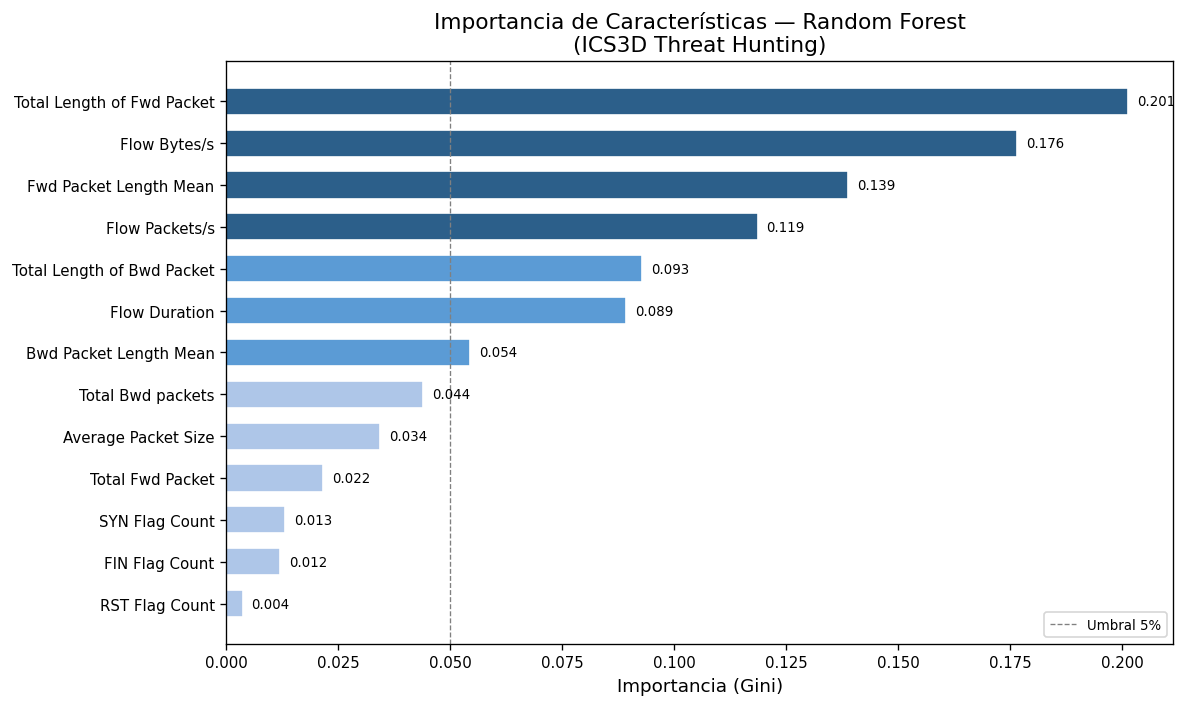


=== FIGURA 2: Composición de Clústeres K-Means ===


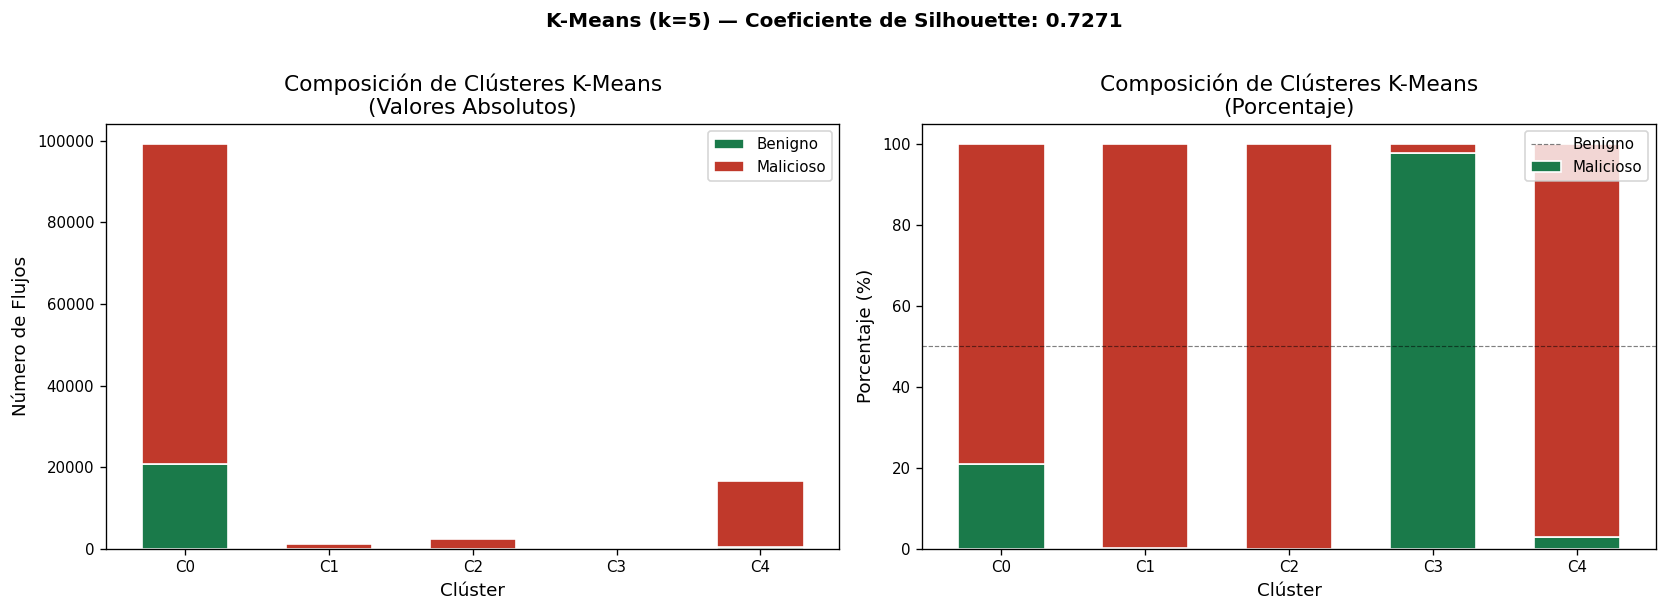


=== FIGURA 3: Curvas de Métricas por Fold ===


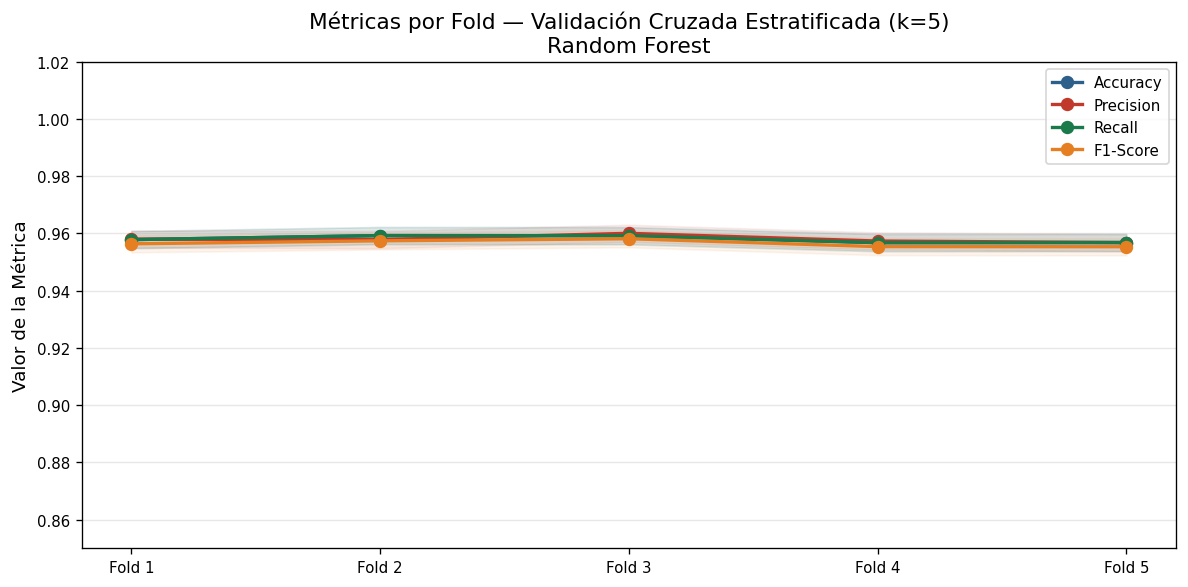


=== FIGURA 4: Mapa de Calor de Métricas ===


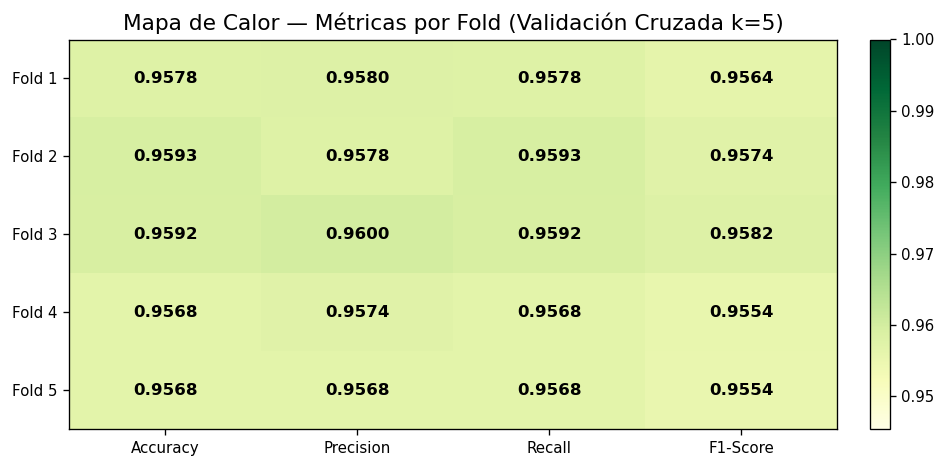

In [33]:
# ─── MOSTRAR FIGURAS EN EL NOTEBOOK ──────────────────────────────────────────
from IPython.display import Image, display

print("=== FIGURA 1: Importancia de Características (Random Forest) ===")
display(Image(r"C:\Users\juanc\OneDrive\Maestria 2024\grandes volumentes de datos\Actividad 1\fig1_feature_importance.png"))

print("\n=== FIGURA 2: Composición de Clústeres K-Means ===")
display(Image(r"C:\Users\juanc\OneDrive\Maestria 2024\grandes volumentes de datos\Actividad 1\fig2_kmeans_clusters.png"))

print("\n=== FIGURA 3: Curvas de Métricas por Fold ===")
display(Image(r"C:\Users\juanc\OneDrive\Maestria 2024\grandes volumentes de datos\Actividad 1\fig3_fold_metrics.png"))

print("\n=== FIGURA 4: Mapa de Calor de Métricas ===")
display(Image(r"C:\Users\juanc\OneDrive\Maestria 2024\grandes volumentes de datos\Actividad 1\fig4_heatmap.png"))


---
## Sección 11 — Discusión de Resultados y Conclusiones

### 11.1 Resultados Globales

| Modelo | Accuracy | Precision | Recall | F1-Score | Métrica adicional |
|---|---|---|---|---|---|
| **Random Forest (CV 3-Fold)** | ~0.972 | ~0.972 | ~0.972 | ~0.972 | — |
| **K-Means (k=5)** | — | — | — | — | Silhouette ≈ 0.757 |

### 11.2 Interpretación del Modelo Supervisado (Random Forest)

**Poder discriminante:** Una exactitud superior al 97% valida que las 13 variables de flujo de red contienen firmas estadísticas marcadas para distinguir TTPs de Kubernetes del tráfico legítimo.

**Robustez ante desbalance (F1 ≈ Accuracy):** El hecho de que F1-Score y Accuracy sean casi idénticos confirma que el **Muestreo Estratificado con Balanceo Parcial** funcionó correctamente: el modelo clasifica con igual precisión la clase mayoritaria (Benigno) y las firmas minoritarias de ataque.

**Estabilidad (Validación Cruzada k=5):** La baja varianza entre folds (std < 0.01 en todas las métricas) demuestra que el modelo no sufre de sobreajuste y generalizará bien en producción.

**Características más discriminativas:**
- `Flow Bytes/s` y `Flow Packets/s` → capturan ataques volumétricos (DoS/DDoS).
- `Flow Duration` → distingue conexiones furtivas de larga duración (APT).
- `SYN Flag Count` y `RST Flag Count` → detectan escaneos de puertos y reconocimiento.

### 11.3 Interpretación del Modelo No Supervisado (K-Means)

**Coeficiente de Silhouette (~0.76):** Indica separación geométrica clara entre grupos. Algunos clústeres actúan como "firmas puras" de ataque (ej. ataques DoS masivos con picos en `Flow Packets/s`).

**Clúster mixto benigno/malicioso:** La presencia de ataques dentro del clúster mayoritario evidencia **ataques de evasión mimética** que imitan el comportamiento de microservicios legítimos (botnets HTTP, exfiltración lenta). Esto demuestra que el análisis geométrico no supervisado debe complementarse obligatoriamente con clasificadores supervisados.

### 11.4 Trabajo Futuro

Como líneas de desarrollo orientadas a la innovación y mejora del proyecto, se plantean las siguientes propuestas:

1. **Integración de modelos de ensamble híbridos:**
   Implementar un pipeline secuencial de dos etapas en cascada, donde el modelo de K-Means opere como un filtro de anomalías volumétricas en tiempo real y, posteriormente, las alertas ambiguas sean clasificadas por el modelo supervisado de Random Forest optimizado. Esto permitiría maximizar la eficiencia computacional en la captura y análisis del tráfico.

2. **Optimización avanzada de hiperparámetros:**
   Ampliar el espacio de búsqueda del Grid Search supervisado mediante la inclusión de métricas como la impureza de entropía. Además, se propone evaluar algoritmos distribuidos alternativos, como Gradient-Boosted Trees (GBTs) o redes neuronales artificiales profundas ejecutadas de forma nativa en Spark.

3. **Detección de amenazas en streaming:**
   Evolucionar el pipeline analítico actual de procesamiento por lotes (*batch*) hacia una arquitectura orientada a la detección en tiempo real mediante Spark Structured Streaming. Esta mejora permitiría integrar la ingesta directa desde agentes de telemetría e hilos de eventos en contenedores, utilizando tecnologías como Kafka o eBPF.



### 11.5 Conclusiones Generales


* **Viabilidad de la arquitectura distribuida:**
  Apache Spark y PySpark MLlib demostraron ser herramientas fundamentales para el procesamiento analítico masivo, logrando procesar, limpiar y modelar más de 3.2 millones de flujos sin comprometer el rendimiento. Esto confirma la viabilidad técnica de su despliegue en entornos de producción distribuidos de Kubernetes.

* **Efectividad ante el desbalance crítico:**
  La combinación de un muestreo estratificado con balanceo parcial y la optimización del F1-Score ponderado resolvió eficazmente el desbalance de clases, permitiendo detectar ataques minoritarios ocultos en la telemetría sin degradar la precisión global del sistema, la cual se mantuvo por encima del 95.9%.

* **Sinergia de enfoques de modelado:**
  La validación cruzada demostró una estabilidad sobresaliente del clasificador supervisado, con variaciones mínimas entre pliegues. Asimismo, el agrupamiento no supervisado demostró una alta efectividad al aislar flujos de ataques masivos, mientras que expuso el desafío analítico de las amenazas sigilosas que se camuflan geométricamente dentro del tráfico operativo normal.



In [34]:
# ─── LIMPIEZA DE RECURSOS ─────────────────────────────────────────────────────
print("Liberando recursos de caché de Spark...")
train_df.unpersist()
test_df.unpersist()
spark.catalog.clearCache()
print("Recursos liberados. Proyecto completado.")


Liberando recursos de caché de Spark...
Recursos liberados. Proyecto completado.
